## Install Once

In [144]:
%pip install -q pandas numpy matplotlib requests flexpolyline openpyxl

Note: you may need to restart the kernel to use updated packages.


## Paths

In [145]:
import os
from pathlib import Path
import shutil

project_root        = Path.cwd()
DATA_DIR            = project_root / "Data"
ROUTES_DIR          = project_root / "Routes"
ROUTES_CLEAN_DIR    = project_root / "Routes Clean"
EMISSIONS_DIR       = project_root / "Routes Emissions"
ROUTE_SUM_DIR       = project_root / "Routes Segment Emissions"
HBEFA_CLEAN_DATA_DIR= project_root / "HBEFA Clean Data"
HBEFA_DATA_DIR      = project_root / "HBEFA Data"

def build_folders():
  
    """
    Create the following folders in the current working directory:
    - Data
    - Routes
    - Routes Clean
    - Routes Emissions
    - HBEFA Clean Data
    - HBEFA Data
    """
    project_root        = Path.cwd()
    DATA_DIR            = project_root / "Data"
    ROUTES_DIR          = project_root / "Routes"
    ROUTES_CLEAN_DIR    = project_root / "Routes Clean"
    EMISSIONS_DIR       = project_root / "Routes Emissions"
    ROUTE_SUM_DIR       = project_root / "Routes Segment Emissions"
    HBEFA_CLEAN_DATA_DIR= project_root / "HBEFA Clean Data"
    HBEFA_DATA_DIR      = project_root / "HBEFA Data"

    for d in (DATA_DIR, ROUTES_DIR, ROUTES_CLEAN_DIR,
          EMISSIONS_DIR, HBEFA_CLEAN_DATA_DIR, HBEFA_DATA_DIR):
        d.mkdir(exist_ok=True)

    return project_root, DATA_DIR, ROUTES_DIR, ROUTES_CLEAN_DIR, EMISSIONS_DIR, HBEFA_CLEAN_DATA_DIR, HBEFA_DATA_DIR

def clear_folders():
    """
    Delete (recursively) the project’s output folders if they exist,
    then recreate them empty so downstream code can write into them.

    Folders cleared / recreated, relative to the notebook’s CWD:
      - Data
      - Routes
      - Routes Clean
      - Routes Emissions
      - HBEFA Clean Data
      - HBEFA Data
    """
    project_root        = Path.cwd()
    DATA_DIR            = project_root / "Data"
    ROUTES_DIR          = project_root / "Routes"
    ROUTES_CLEAN_DIR    = project_root / "Routes Clean"
    EMISSIONS_DIR       = project_root / "Routes Emissions"
    ROUTE_SUM_DIR       = project_root / "Routes Segment Emissions"
    HBEFA_CLEAN_DATA_DIR= project_root / "HBEFA Clean Data"
    HBEFA_DATA_DIR      = project_root / "HBEFA Data"

    for d in (DATA_DIR, ROUTES_DIR, ROUTES_CLEAN_DIR,
              EMISSIONS_DIR, ROUTE_SUM_DIR):
        if d.exists():
            shutil.rmtree(d)      # remove the folder and everything in it
        d.mkdir(parents=True, exist_ok=True)

    for d in (HBEFA_CLEAN_DATA_DIR, HBEFA_DATA_DIR):
        d.mkdir(parents=True, exist_ok=True)

    return project_root, DATA_DIR, ROUTES_DIR, ROUTES_CLEAN_DIR, EMISSIONS_DIR, HBEFA_CLEAN_DATA_DIR, HBEFA_DATA_DIR




## Generate Coordinates

In [146]:
import requests
import urllib.parse

def get_coordinates(start, end):

    locations = [start, end]
    locations_coords = []

    for location in locations:

        encoded_location = urllib.parse.quote(location)

        headers = {
            'Accept': 'application/json, application/geo+json, application/gpx+xml, img/png; charset=utf-8',
        }

        url = f'https://api.openrouteservice.org/geocode/search?api_key=5b3ce3597851110001cf6248b9817ea066594ff4b590e271021b0633&text={encoded_location}&boundary.country=GBR&layers=address,postalcode&size=1'
        call = requests.get(url, headers=headers)

        if call.status_code == 200:
            data = call.json()
            if data.get("features"):
                features = data["features"][0]
                coordinates = features["geometry"]["coordinates"][::-1]
                label = features["properties"]["label"]
                print("Coordinates:", coordinates)
                print("Label:", label)
                locations_coords.append(coordinates)
            else:
                print("No features found in the response.")
        else:
            print("Request failed:", call.status_code, call.reason)

    return locations_coords

## Generate Routes

In [147]:
from pathlib import Path
import json
import requests
import pandas as pd     # still imported because you said you need it later

def get_route(locations_coords, vehicle_type, route_mode,
              departure_time, number_alternatives, DATA_DIR):
    if not locations_coords or len(locations_coords) < 2:
        raise ValueError("At least two coordinates (origin & destination) are required")

    api_key = "ampQkKtRBHju57U3exZDky2F9oykA1j56mAYKrFjiRg"

    if vehicle_type == "LCV" or vehicle_type == "HGV":
        vehicle_type = "truck"
    elif vehicle_type == "car":
        vehicle_type = "car"

    url = (
        f"https://router.hereapi.com/v8/routes?"
        f"apiKey={api_key}&"
        f"origin={locations_coords[0][0]},{locations_coords[0][1]}&"
        f"destination={locations_coords[1][0]},{locations_coords[1][1]}&"
        f"transportMode={vehicle_type}&"
        f"routingMode={route_mode}&"
        f"departureTime={departure_time}&"
        f"return=elevation,polyline,summary,typicalDuration,turnByTurnActions&"
        f"spans=streetAttributes,carAttributes,names,length,duration,baseDuration,"
        f"typicalDuration,maxSpeed,dynamicSpeedInfo&"
        f"alternatives={number_alternatives}"
    )
    response = requests.post(url, json={}, headers={"Content-Type": "application/json"})
    response.raise_for_status()              # let Python throw if we didn’t get 200

    DATA_DIR.mkdir(exist_ok=True)
    data = response.json()
    (DATA_DIR / "route.txt").write_text(json.dumps(data, indent=2))
    print("JSON written to", (DATA_DIR / 'route.txt').relative_to(project_root))

    # Return the polylines exactly as before
    polylines = [
        section["polyline"]
        for route in data.get("routes", [])
        for section in route.get("sections", [])
        if section.get("polyline")
    ]
    return polylines


## Plot Polylines

In [148]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import flexpolyline as fpl
from pathlib import Path

def plot_polylines(polylines, DATA_DIR):
    """
    • combined plot  → data_dir/Polyline.png
    • individual     → data_dir/Polyline_route-<n>.png
    """
    DATA_DIR.mkdir(exist_ok=True)

    colors     = ['red', 'blue', 'green', 'orange', 'purple', 'black']
    linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]

    # ── A) combined figure ───────────────────────────────────────
    fig_c, ax_c = plt.subplots(figsize=(10, 6))

    for idx, encoded in reversed(list(enumerate(polylines, start=1))):
        lats, lons = zip(*[(lat, lon) for lat, lon, *_ in fpl.decode(encoded)])

        colour = colors[(idx - 1) % len(colors)]
        style  = linestyles[(idx - 1) % len(linestyles)]
        z      = 5 + idx

        ax_c.plot(lons, lats, lw=2, linestyle=style, color=colour,
                  label=f'Route {idx}', zorder=z,
                  path_effects=[pe.Stroke(linewidth=5, foreground='white'),
                                pe.Normal()])
        ax_c.plot(lons[0],  lats[0], marker='o', markersize=7,
                  markerfacecolor=colour, markeredgecolor='black', zorder=z+0.5)
        ax_c.plot(lons[-1], lats[-1], marker='x', markersize=9,
                  color=colour, markeredgewidth=2, zorder=z+0.5)

    ax_c.set(title='Decoded Routes from Flexible Polyline',
             xlabel='Longitude', ylabel='Latitude')
    ax_c.axis('equal'); ax_c.grid(True); ax_c.legend()

    comb_path = DATA_DIR / "Polyline.png"
    fig_c.savefig(comb_path, dpi=300, bbox_inches="tight")
    plt.close(fig_c)
    print("✓ combined plot:", comb_path.relative_to(Path.cwd()))

    # ── B) one figure per route ─────────────────────────────────
    for idx, encoded in enumerate(polylines, start=1):
        lats, lons = zip(*[(lat, lon) for lat, lon, *_ in fpl.decode(encoded)])

        colour = colors[(idx - 1) % len(colors)]
        style  = linestyles[(idx - 1) % len(linestyles)]

        fig, ax = plt.subplots(figsize=(7, 5))

        ax.plot(lons, lats, lw=2, linestyle=style, color=colour,
                path_effects=[pe.Stroke(linewidth=5, foreground='white'),
                              pe.Normal()])
        ax.plot(lons[0],  lats[0], marker='o', markersize=7,
                markerfacecolor=colour, markeredgecolor='black')
        ax.plot(lons[-1], lats[-1], marker='x', markersize=9,
                color=colour, markeredgewidth=2)

        ax.set(title=f'Route {idx}', xlabel='Longitude', ylabel='Latitude')
        ax.axis('equal'); ax.grid(True)

        out_path = DATA_DIR / f"Polyline_route-{idx}.png"
        fig.savefig(out_path, dpi=300, bbox_inches='tight')
        plt.close(fig)
        print("✓ saved", out_path.relative_to(Path.cwd()))



## Build Route Data

In [149]:
from pathlib import Path
import json
import pandas as pd

# ────────────────────────────────────────────────────────────────
#  Helper stays the same
# ────────────────────────────────────────────────────────────────
def assign_road_type(road_number):
    if not isinstance(road_number, str) or not road_number:
        return "Local"
    if road_number.startswith("M"):
        return "MW"
    if road_number.startswith("A"):
        digits = road_number[1:]
        if digits.isdigit():
            if len(digits) == 1:
                return "Trunk"
            elif len(digits) == 2:
                return "Distr"
            else:
                return "Local"
    if road_number.startswith("B"):
        return "Access"
    return "n/a"

# ────────────────────────────────────────────────────────────────
#  Cleaning function (unchanged except type hints)
# ────────────────────────────────────────────────────────────────
def clean_route_folder(input_folder: Path, output_dir_name: str = "Routes Clean"):
    input_dir = Path(input_folder)
    output_dir = input_dir.parent / output_dir_name
    output_dir.mkdir(parents=True, exist_ok=True)

    for file_path in input_dir.iterdir():
        if file_path.stem.endswith("_clean"):
            continue
        if file_path.suffix.lower() not in {".csv", ".xlsx", ".xls"}:
            continue

        # Load data
        df = (
            pd.read_csv(file_path)
            if file_path.suffix.lower() == ".csv"
            else pd.read_excel(file_path)
        )

        # Transform
        df["road_type"] = df["road_number"].apply(assign_road_type)
        df_clean = (
            df[["distance_m", "maxSpeed_km_per_h", "trafficSpeed_km_per_h", "road_type"]]
            .rename(
                columns={
                    "distance_m": "distance(m)",
                    "maxSpeed_km_per_h": "speed_limit(km/h)",
                    "trafficSpeed_km_per_h": "vehicle_speed(km/h)",
                }
            )
        )

        # Save
        out_file = output_dir / f"{file_path.stem}_clean{file_path.suffix}"
        (df_clean.to_csv if out_file.suffix == ".csv" else df_clean.to_excel)(
            out_file, index=False
        )
        print("✓ cleaned", out_file.relative_to(input_dir.parent))

# ────────────────────────────────────────────────────────────────
#  Main routine turned into a function with arguments
# ────────────────────────────────────────────────────────────────
def process_meter_data(api_json: Path, routes_dir: Path):
    routes_dir.mkdir(exist_ok=True)
    data = json.loads(api_json.read_text())
    routes = data.get("routes", [])

    for i, route in enumerate(routes, start=1):
        section = route.get("sections", [])[0]
        summary = section.get("summary", {})
        journey_length = summary.get("length", 0)
        df = pd.DataFrame(index=range(1, journey_length + 1))
        df.index.name = "distance_m"

        # save journey duration
        journey_duration = summary.get("typicalDuration", 0)
        if 'journey_durations' not in locals():
            journey_durations = pd.DataFrame(columns=["route_index", "journey_duration"])
        journey_durations = pd.concat(
            [journey_durations, pd.DataFrame({"route_index": [i], "journey_duration": [journey_duration]})],
            ignore_index=True
        )
        out_path = DATA_DIR / f"journey_durations.csv"
        journey_durations.to_csv(out_path, index=False)
        print(f"✓ journey durations saved")

        # -------------- your original STEPS 1–5 unmodified -------------
        df["maxSpeed_km_per_h"] = None
        df["trafficSpeed_km_per_h"] = None
        df["baseSpeed_km_per_h"] = None

        spans = section.get("spans", [])
        cumulative_meter = 0
        for span in spans:
            span_length = span.get("length", 0)
            if span_length <= 0:
                continue
            max_speed = span.get("maxSpeed")
            dyn = span.get("dynamicSpeedInfo", {})
            traffic_speed = dyn.get("trafficSpeed")
            base_speed = dyn.get("baseSpeed")

            max_kmh = max_speed * 3.6 if max_speed is not None else None
            traf_kmh = traffic_speed * 3.6 if traffic_speed is not None else None
            base_kmh = base_speed * 3.6 if base_speed is not None else None

            start = cumulative_meter + 1
            end = cumulative_meter + span_length
            df.loc[start:end, "maxSpeed_km_per_h"] = max_kmh
            df.loc[start:end, "trafficSpeed_km_per_h"] = traf_kmh
            df.loc[start:end, "baseSpeed_km_per_h"] = base_kmh

            cumulative_meter += span_length

        df["road"] = None
        df["road_number"] = None
        df["actions"] = None

        tbt = section.get("turnByTurnActions", [])
        cumulative = 0
        for act in tbt:
            seg_len = act.get("length", 0)
            start = cumulative + 1
            end = cumulative + seg_len
            cumulative += seg_len

            road = act.get("nextRoad", {}).get("name", [{}])[0].get("value", "")
            number = act.get("nextRoad", {}).get("number", [{}])[0].get("value", "")
            desc = act.get("action", "")
            if "direction" in act:
                desc += f" ({act['direction']})"

            df.loc[start:end, "road"] = road
            df.loc[start:end, "road_number"] = number
            if desc:
                df.loc[start, "actions"] = desc

        df["actions"] = df["actions"].shift(-1)

        cols = [
            "maxSpeed_km_per_h",
            "trafficSpeed_km_per_h",
            "baseSpeed_km_per_h",
            "road",
            "road_number",
            "actions",
        ]
        comp = df.fillna("").ne(df.fillna("").shift())[cols].any(axis=1)
        df_compressed = df[comp].copy()

        df_compressed["road_type"] = df_compressed["road_number"].apply(
            assign_road_type
        )

        out_path = routes_dir / f"route_{i}.csv"
        df_compressed.to_csv(out_path, index=True)
        print(f"✓ route {i} saved")



## Clean HBEFA Data

In [150]:
from pathlib import Path
import pandas as pd

# ────────────────────────────────────────────────────────────────
#  1.  Helper: clean a single worksheet (unchanged logic)
# ────────────────────────────────────────────────────────────────
def build_emission_db_pc(excel_file: Path, sheet_name=0) -> pd.DataFrame:
    """
    Reads a sheet formatted like PC.xlsx and returns the tidy DataFrame:

    ['component', 'environment', 'road_type', 'speed_limit',
     'traffic', 'Average_speed', 'Emission_factor']
    """
    df = pd.read_excel(excel_file, sheet_name=sheet_name)

    pieces = df["TrafficSit"].str.split("/", expand=True)
    pieces.columns = ["environment", "road_type", "speed_limit", "traffic"]

    df["environment"] = pieces["environment"]
    df["road_type"]   = pieces["road_type"]

    df["speed_limit"] = pd.to_numeric(pieces["speed_limit"].str.replace(">", ""),
                                       errors="coerce")
    df["traffic"] = pieces["traffic"]

    return (
        df[["Component", "environment", "road_type", "speed_limit",
            "traffic", "V_weighted", "EFA_weighted"]]
        .rename(columns={
            "Component":    "component",
            "V_weighted":   "Average_speed",
            "EFA_weighted": "Emission_factor",
        })
    )

# ────────────────────────────────────────────────────────────────
#  2.  Batch-clean an entire folder
# ────────────────────────────────────────────────────────────────
def clean_all_excels(input_dir,
                     output_dir_name) -> None:
    """
    Cleans every *.xlsx* (case-insensitive) in *input_dir* and writes the
    results to *output_dir_name* sitting **beside** *input_dir*.
    """
    input_dir   = Path(input_dir)
    output_dir  = input_dir.parent / output_dir_name
    output_dir.mkdir(parents=True, exist_ok=True)

    excel_files = list(input_dir.glob("*.xlsx")) + list(input_dir.glob("*.XLSX"))
    if not excel_files:
        print("No Excel files found in", input_dir)
        return

    for f in excel_files:
        if f.stem.endswith("_clean"):
            continue
        cleaned = build_emission_db_pc(f)
        out_path = output_dir / f"{f.stem}_clean.xlsx"
        cleaned.to_excel(out_path, index=False)
        print("✓", out_path.relative_to(output_dir.parent))




## Estimate Emissions

In [151]:
import pandas as pd
import numpy as np
from pathlib import Path

def assign_emission_factors_to_routes(route_folder: str,
                                      vehicle_type: str,
                                      HBEFA_CLEAN_DATA_DIR,
                                      output_dir_name: str = 'Routes Emissions'):
    """
    Reads every *_clean.csv in route_folder, and for each row:
      - extracts road_type, speed_limit, and vehicle_speed
      - for each pollutant/component in the vehicle_type EF table, interpolates
        the emission factor based on those properties
      - adds a column per component with its emission factor
    Saves the enriched files to a sibling folder named output_dir_name.
    """
    route_folder = Path(route_folder)
    # Load the EF table once


    ## Special case for each type of vehicle
    NAME_MAP = {
    "car": "PC",       # passenger car
    # add more special cases if needed
    }

    stem = NAME_MAP.get(vehicle_type.lower(), vehicle_type.upper())
    ef_path = Path(HBEFA_CLEAN_DATA_DIR) / f"{stem}_clean.xlsx"  # updated to use stem
    if not ef_path.exists():
        raise FileNotFoundError(f"Emission-factor file not found: {ef_path}")
    ef_df = pd.read_excel(ef_path)
    
    components = ef_df['component'].unique()
    
    # Prepare output directory
    output_dir = route_folder.parent / output_dir_name
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Column names in route files
    sl_col = 'speed_limit(km/h)'
    vs_col = 'vehicle_speed(km/h)'
    
    for route_file in route_folder.glob("*_clean.csv"):
        df_route = pd.read_csv(route_file)
        
        # For each component, compute EF column
        for comp in components:
            def compute_ef(row):
                rt = row['road_type']
                sl = row[sl_col]
                vs = row[vs_col]
                
                # Filter EF table
                subset = ef_df[
                    (ef_df['component'] == comp) &
                    (ef_df['road_type'] == rt) &
                    (ef_df['speed_limit'] == sl)
                ].sort_values('Average_speed')
                
                if subset.empty:
                    # nearest speed_limit fallback
                    avail = ef_df[
                        (ef_df['component'] == comp) &
                        (ef_df['road_type'] == rt)
                    ]['speed_limit'].dropna().unique()
                    if len(avail) == 0:
                        return np.nan
                    nearest = min(avail, key=lambda x: abs(x - sl))
                    subset = ef_df[
                        (ef_df['component'] == comp) &
                        (ef_df['road_type'] == rt) &
                        (ef_df['speed_limit'] == nearest)
                    ].sort_values('Average_speed')
                
                speeds = subset['Average_speed'].to_numpy()
                emis   = subset['Emission_factor'].to_numpy()
                return float(np.interp(vs, speeds, emis, left=emis[0], right=emis[-1]))
            
            df_route[comp] = df_route.apply(compute_ef, axis=1)
        
        # Save enriched route
        out_name = route_file.stem + '_emissions.csv'
        df_route.to_csv(output_dir / out_name, index=False)
        print(f"Saved: {output_dir / out_name}")

def save_segment_emissions_with_summary(route_emissions_folder: str,
                                        output_folder_name: str = "Routes Segment Emissions"):
    """
    Processes each *_clean_emissions.csv in route_emissions_folder:
      1) computes per-segment emissions (g) and saves as *_segment_emissions.csv
      2) aggregates per-route total emissions and writes a combined summary CSV
         named all_routes_summary.csv in the same output folder
    """
    input_dir = Path(route_emissions_folder)
    output_dir = input_dir.parent / output_folder_name
    output_dir.mkdir(parents=True, exist_ok=True)

    summary_list = []

    for file in input_dir.glob("*_clean_emissions.csv"):
        df = pd.read_csv(file)

        # Compute segment distances (m): next distance minus current
        distances = df["distance(m)"].to_numpy()
        segment_m = np.empty_like(distances, dtype=float)
        segment_m[:-1] = distances[1:] - distances[:-1]
        segment_m[-1] = 0  
        segment_km = segment_m / 1000.0

        # Identify pollutant columns (all except metadata)
        metadata = {"distance(m)", "speed_limit(km/h)", "vehicle_speed(km/h)", "road_type"}
        pollutant_cols = [c for c in df.columns if c not in metadata]

        # Calculate emissions in grams per segment
        df_emissions = pd.DataFrame(index=df.index)
        df_emissions["distance(m)"] = df["distance(m)"]
        for col in pollutant_cols:
            df_emissions[col] = df[col] * segment_km

        # Save per-segment emissions file
        out_seg = output_dir / file.name.replace("_clean_emissions.csv", "_segment_emissions.csv")
        df_emissions.to_csv(out_seg, index=False)

        # Get journey duration from data file
        journey_durations = pd.read_csv(DATA_DIR / "journey_durations.csv")

        # Aggregate per-route totals
        totals = {"distance(m)": df_emissions["distance(m)"].iloc[-1]}
        totals["journey_duration(min)"] = journey_durations.loc[journey_durations["route_index"] == int(file.stem.split("_")[1]), "journey_duration"].values[0]/60
        totals.update(df_emissions[pollutant_cols].sum().to_dict())
        route_name = file.stem.replace("_clean_emissions", "")
        record = {"route": route_name, **totals}
        summary_list.append(record)

    # Build combined summary DataFrame and save
    summary_df = pd.DataFrame(summary_list)
    out_summary = output_dir / "all_routes_summary.csv"
    summary_df.to_csv(out_summary, index=False)

    print(f"Saved combined summary: {out_summary}")


## Display Data

project_root        = Path.cwd()
    DATA_DIR            = project_root / "Data"
    ROUTES_DIR          = project_root / "Routes"
    ROUTES_CLEAN_DIR    = project_root / "Routes Clean"
    EMISSIONS_DIR       = project_root / "Routes Emissions"
    ROUTE_SUM_DIR       = project_root / "Routes Segment Emissions"
    HBEFA_CLEAN_DATA_DIR= project_root / "HBEFA Clean Data"
    HBEFA_DATA_DIR      = project_root / "HBEFA Data"

In [167]:
# ▼ drop this entire cell into the notebook and run
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.stats import linregress

def display_emissions_summary():
    """
    Summarise route-level emissions with
      • absolute totals
      • per-km (g / km, mg / km)
      • per-min (g / min, mg / min)
      • Δ-% vs the fastest (base) route
    and show bar charts + radar plot.
    """

    # ─── 1. Load data ──────────────────────────────────────────────
    summary = pd.read_csv(ROUTE_SUM_DIR / "all_routes_summary.csv")
    BASE_ROUTE = summary.loc[summary["journey_duration(min)"].idxmin(), "route"]

    # ─── 2. Δ-% columns vs base ────────────────────────────────────
    metrics = ["journey_duration(min)", "distance(m)",
               "CO2(total)", "NOx", "PM2.5"]
    for m in metrics:
        base_val = summary.loc[summary["route"] == BASE_ROUTE, m].iat[0]
        summary[f"{m} Δ%"] = 100 * (summary[m] - base_val) / base_val

    # ─── 3. NEW per-km & per-min columns ───────────────────────────
    km  = summary["distance(m)"] / 1000
    min = summary["journey_duration(min)"].replace(0, np.nan)          # avoid /0

    summary["CO2_g/km"]      = summary["CO2(total)"] / km
    summary["CO2_g/min"]     = summary["CO2(total)"] / min
    summary["NOx_mg/km"]     = summary["NOx"]   * 1000 / km
    summary["NOx_mg/min"]    = summary["NOx"]   * 1000 / min
    summary["PM2.5_mg/km"]   = summary["PM2.5"] * 1000 / km
    summary["PM2.5_mg/min"]  = summary["PM2.5"] * 1000 / min

    # ─── 4. Styled Δ-% + per-unit table ────────────────────────────
    flat = [c for m in metrics for c in (m, f"{m} Δ%")]
    extra = ["CO2_g/km","CO2_g/min","NOx_mg/km","NOx_mg/min",
             "PM2.5_mg/km","PM2.5_mg/min"]
    view = summary[["route"] + flat + extra]

    styled = (view.style
        .format({**{"distance(m)":"{:,.0f}"},
                 **{c:"{:+.1f}%" for c in view if c.endswith("Δ%")},
                 **{c:"{:.1f}"   for c in extra}})
        .background_gradient(cmap="RdYlGn_r",
                             subset=[c for c in view if c.endswith("Δ%")],
                             vmin=-20, vmax=20)
        .set_caption(f"Base route = {BASE_ROUTE!r} (fastest)"))
    display(styled)

    # ─── 5. Bar charts ─────────────────────────────────────────────
    # a) absolute totals
    fig1, ax1 = plt.subplots(figsize=(7.5,4))
    summary.plot(x="route", y=["CO2(total)", "NOx", "PM2.5"],
                 kind="bar", ax=ax1, width=0.7)
    ax1.set(title="Total emissions per route", ylabel="grams")
    ax1.grid(True, ls=":"); plt.xticks(rotation=0); plt.tight_layout()
    fig1.savefig(DATA_DIR / "emissions_absolute.png", dpi=300)

    # b) per-km
    fig2, ax2 = plt.subplots(figsize=(7.5,4))
    summary.plot(x="route", y=["CO2_g/km","NOx_mg/km","PM2.5_mg/km"],
                 kind="bar", ax=ax2, width=0.7)
    ax2.set(title="Per-kilometre emissions", ylabel="g or mg / km")
    ax2.grid(True, ls=":"); plt.xticks(rotation=0); plt.tight_layout()
    fig2.savefig(DATA_DIR / "emissions_per_km.png", dpi=300)

    # c) NEW per-min
    fig3, ax3 = plt.subplots(figsize=(7.5,4))
    summary.plot(x="route", y=["CO2_g/min","NOx_mg/min","PM2.5_mg/min"],
                 kind="bar", ax=ax3, width=0.7)
    ax3.set(title="Per-minute emissions (typical duration)",
            ylabel="g or mg / min")
    ax3.grid(True, ls=":"); plt.xticks(rotation=0); plt.tight_layout()
    fig3.savefig(DATA_DIR / "emissions_per_min.png", dpi=300)

    # ─── 6. Radar plot & score (unchanged) ─────────────────────────
    weights = {"CO2(total)":1, "NOx":1, "PM2.5":1,
               "distance(m)":0.5, "journey_duration(min)":0.5}

    norm = {m:(summary[m]-summary[m].min())/(summary[m].max()-summary[m].min() or 1)
            for m in weights}
    summary["score"]=sum(weights[m]*norm[m] for m in weights)
    best_route = summary.loc[summary["score"].idxmin(), "route"]

    angles = np.linspace(0,2*np.pi,len(weights),endpoint=False).tolist()+[0]
    fig4,ax4=plt.subplots(subplot_kw=dict(polar=True),figsize=(6,6))
    for i,row in summary.iterrows():
        vals=[norm[m].iloc[i] for m in weights]+[norm[list(weights)[0]].iloc[i]]
        ax4.plot(angles,vals,label=row["route"],
                 lw=2,path_effects=[pe.Stroke(linewidth=4,foreground='white'),pe.Normal()])
    ax4.set_xticks(angles[:-1]); ax4.set_xticklabels(weights.keys(),fontsize=9)
    ax4.set_title("Normalised performance radar\n(lower = better)")
    ax4.legend(bbox_to_anchor=(1.05,1.0),loc="upper left")
    plt.tight_layout(); fig4.savefig(DATA_DIR/"performance_radar.png",dpi=300); plt.show()

    # ─── 7. Narrative summary ─────────────────────────────────────
    print("Recommended route by weighted score:", best_route)
    print("\nPer-km CO₂ (g/km) ranking:")
    display(summary[["route","CO2_g/km"]].sort_values("CO2_g/km"))
    print("\nPer-min CO₂ (g/min) ranking:")
    display(summary[["route","CO2_g/min"]].sort_values("CO2_g/min"))


## Run Programme

Building folders...
Starting coordinate lookup...
Coordinates: [51.499683, -0.169237]
Label: SW7 1AP, London, England, United Kingdom
Coordinates: [51.504937, -0.019523]
Label: E14 5AB, London, England, United Kingdom
Getting route data...
JSON written to Data/route.txt
Plotting polylines...
✓ combined plot: Data/Polyline.png
✓ saved Data/Polyline_route-1.png
✓ saved Data/Polyline_route-2.png
✓ saved Data/Polyline_route-3.png
✓ saved Data/Polyline_route-4.png
✓ saved Data/Polyline_route-5.png
✓ saved Data/Polyline_route-6.png
✓ saved Data/Polyline_route-7.png
Processing meter data...
✓ journey durations saved
✓ route 1 saved
✓ journey durations saved
✓ route 2 saved
✓ journey durations saved
✓ route 3 saved
✓ journey durations saved
✓ route 4 saved
✓ journey durations saved
✓ route 5 saved
✓ journey durations saved
✓ route 6 saved
✓ journey durations saved
✓ route 7 saved
✓ cleaned Routes Clean/route_2_clean.csv
✓ cleaned Routes Clean/route_3_clean.csv
✓ cleaned Routes Clean/route_1_cl

,route,journey_duration(min),journey_duration(min) Δ%,distance(m),distance(m) Δ%,CO2(total),CO2(total) Δ%,NOx,NOx Δ%,PM2.5,PM2.5 Δ%,CO2_g/km,CO2_g/min,NOx_mg/km,NOx_mg/min,PM2.5_mg/km,PM2.5_mg/min
0,route_2,40.266667,+10.7%,"15,619",+7.8%,2986.544715,+8.7%,8.127936,+9.5%,0.110762,+9.7%,191.2,74.2,520.4,201.9,7.1,2.8
1,route_3,41.783333,+14.8%,"15,620",+7.9%,2893.243054,+5.3%,7.484045,+0.9%,0.109030,+8.0%,185.2,69.2,479.1,179.1,7.0,2.6
2,route_1,36.383333,+0.0%,"14,483",+0.0%,2747.127431,+0.0%,7.419682,+0.0%,0.100954,+0.0%,189.7,75.5,512.3,203.9,7.0,2.8
3,route_7,46.866667,+28.8%,"17,452",+20.5%,3401.265444,+23.8%,9.275502,+25.0%,0.126070,+24.9%,194.9,72.6,531.5,197.9,7.2,2.7
4,route_6,44.116667,+21.3%,"15,796",+9.1%,3109.362008,+13.2%,8.344255,+12.5%,0.115984,+14.9%,196.8,70.5,528.3,189.1,7.3,2.6
5,route_5,42.883333,+17.9%,"15,595",+7.7%,2945.897839,+7.2%,7.720969,+4.1%,0.111458,+10.4%,188.9,68.7,495.1,180.0,7.1,2.6
6,route_4,42.183333,+15.9%,"16,564",+14.4%,3176.516969,+15.6%,8.608866,+16.0%,0.116818,+15.7%,191.8,75.3,519.7,204.1,7.1,2.8


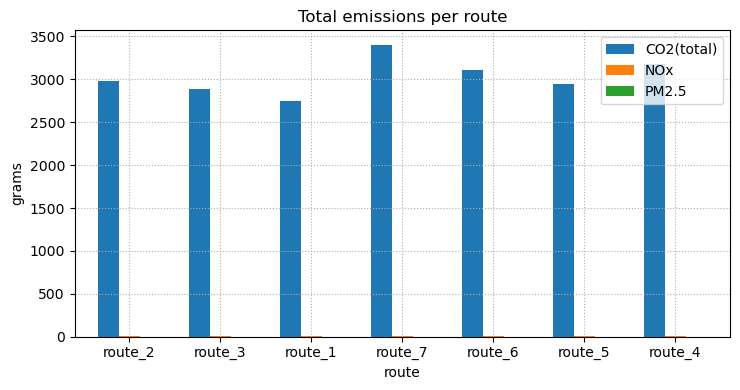

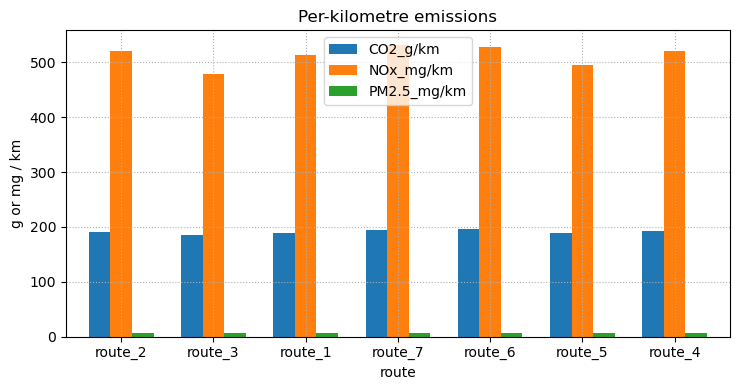

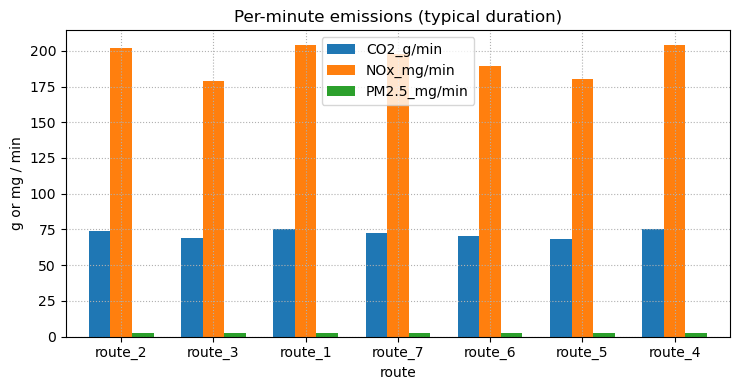

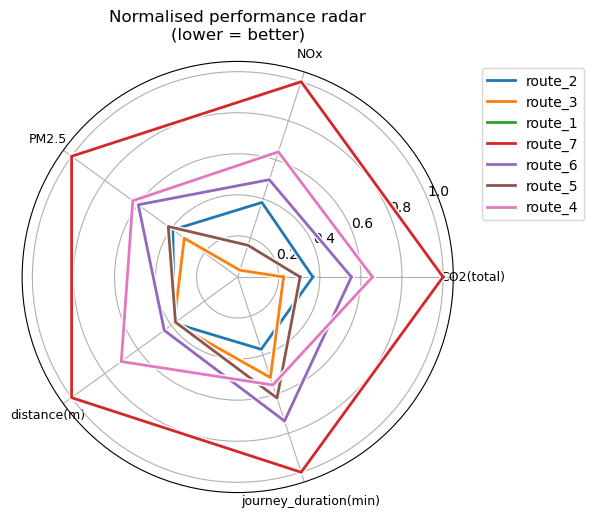

Recommended route by weighted score: route_1

Per-km CO₂ (g/km) ranking:


,route,CO2_g/km
1,route_3,185.226828
5,route_5,188.900150
2,route_1,189.679447
0,route_2,191.212287
6,route_4,191.772336
3,route_7,194.892588
4,route_6,196.844898



Per-min CO₂ (g/min) ranking:


,route,CO2_g/min
5,route_5,68.695636
1,route_3,69.243950
4,route_6,70.480438
3,route_7,72.573231
0,route_2,74.169157
6,route_4,75.302654
2,route_1,75.505106


In [174]:
# Route Variables

# Start and End Postcode
start = "SW7 1AP"
end = "E14 5AB"
# end = "IG8 0TP"

# Routing characteristics
vehicle_type = "car" # car / LCV / HGV
route_mode = "fast" # short / fast
departure_time = "2025-02-23T12:00:00+00:00" # 2025-02-20T13:08:00+00:00
number_alternatives = "6" # 0 <= n <= 6

def main(): 
    print("Building folders...")
    # project_root, DATA_DIR, ROUTES_DIR, ROUTES_CLEAN_DIR, EMISSIONS_DIR, HBEFA_CLEAN_DATA_DIR, HBEFA_DATA_DIR = build_folders()
    project_root, DATA_DIR, ROUTES_DIR, ROUTES_CLEAN_DIR, EMISSIONS_DIR, HBEFA_CLEAN_DATA_DIR, HBEFA_DATA_DIR = clear_folders()

    print("Starting coordinate lookup...") 
    locations_coords = get_coordinates(start, end)

    print("Getting route data...")
    polylines = get_route(locations_coords, vehicle_type, route_mode, departure_time, number_alternatives, DATA_DIR)

    print("Plotting polylines...")
    plot_polylines(polylines, DATA_DIR)                 # plain axes

    print("Processing meter data...")
    process_meter_data(DATA_DIR / "route.txt", ROUTES_DIR)
    clean_route_folder(ROUTES_DIR) 

    print("Cleaning HBEFA data...")
    clean_all_excels(HBEFA_DATA_DIR, HBEFA_CLEAN_DATA_DIR)

    print("Estimating emissions...")
    output_dir_name = "Routes Emissions"  # Define the output directory name
    assign_emission_factors_to_routes(
    route_folder=ROUTES_CLEAN_DIR,
    vehicle_type=vehicle_type,
    HBEFA_CLEAN_DATA_DIR=HBEFA_CLEAN_DATA_DIR,
    output_dir_name=output_dir_name
    )
    save_segment_emissions_with_summary(EMISSIONS_DIR)

    display_emissions_summary()


main()

## Only works with upgrade


In [ ]:
# import requests, json
# from pathlib import Path

# # ────────────────────────────────────────────────────────────────
# # 1.  Replace the TWO placeholders below with real values
# # ────────────────────────────────────────────────────────────────
# API_KEY      = "d1TI23Ez8RNbwcOvNaZcN0vlkXHddOvVrVMQWWN6unc"           # ← put your key here
# FLEX_POLY    = ("B2ForpniD3nqK8kBsiB3JUvCvgBUU3IA4SnGU0KjDU08B3I8B0P7BU7B41BTT8VAAwHATsYAA8GAToaTAwbAT8pBATsiBT_EkwBTvC4mBAA8VTAkhBAT4zC7BA0eAAoQA8B0jBTkD4cAwC0UA4DkSAwCgPAkI4rBAsJ8pBAwCsOAoG0zDAoB4NAoGsYAkI8pBUwRsoDjDgFsTTwH0jBAwCgUAUkSAUsOAA4IA7BwWUUgyBU8B8QA0FoaUkIsTUkI4SoBkXsxB8B4IkSUkI0PTwHsJA8L4XTsT0oBTsJkSA0F0KAwC0FAge46BoBgKkSUgK4SU4DwMA0P0eUwRsiBU8LkXU8GsOA4S8kBA4I8QAwW0tBAsOkmBAkDkIA7G4IArYoa7B_EsEA7L0KT3SkSnBnGoGAvHwHTzKgKTzP0PT7GwHT7LoLAnGoGTrEsEA3IwHAvCwCA3IoLTnB4DAAsEA8BgKAgFkNAkDwHA4DsJUoBkIA0FgPAkD4IAkD4IAwbwtCA0ew3CUwCwHA4SgyBA0F0PA0F0PAwCwHA4DsJAgFkNA8GsTU0PkrBA8QwvBAsEwMAwHoVA8GkXA8BoQA7BoGA7BwCAvC8BA3NoGT3I4DT3I4DA7GgFTvCoGATsEAnBwWA8BsTAoB0FAAwHAjD8LAvCsEA7B8BAnBAAjD8VA_EkNA7BoLT3NosCTvCwMUvC4NArO4zCAzFkcAT4DAzF4XT_EwWAwHgFAsEwCA4DwCA0F4DAsE4DA8LsJA0FsEAgFsETkNgKA4SgPA4DkDAwM0KAkNkNAgK0KAkN0PA4IoLAkX4hBAkIkNA0PgeAgP0jBA0FoQAoLwgBA4I4cAsJ8fAgF0UA0FkXA4DkSAoGwbA0F4cAkI8zBAkD8VA8BsTAwCwbAkD8fAoB0ZAoB8kBAA0tBAA4_BTTwlBUAsYAT0tBAA4IAAgKAUwlBAUk1BAU0tBTAgtBnBA0jBA7B4kCoBAsOAoB0PAoBoVUAgKAsEssBAoGkrBA8BoVUAwqBAnBwtCAjD4xDUnB4mBAnBkmBUA0FA7BwWAnBkNA7GsxBAvCgUA7B8QAjD4XA3DoaArEoaTvCwMA7G4mBA7B0KAnB8GA7BoLA7GwqBUvHgjBAjNkrBT_E8QAnGsdArE0eArE0eA_EgjBAjDsTAzF8pBArE4hBAzF0tBArE8kBT3D0ZUvCkSAjDkXA3DofAnB0UUUkSU4DkcUoGwWoBkNkhBUsE4NAkDsJAwC8LAoBkNATkcU3DopBArEgUT7B8LAToGAUkhBT8B0jBA8BgUAkDwWTkIgjBU4IgjBUwC0KAwC8LAvCoLAnBkIAvC8GAjIgKArJgKAvHoGA7GkIAjI4ITnGoGAvHsJAvHwHA3IoaAvH4XT7LokBTjD8LTnBgKAUoQA0F8pBU0F8pBT8GsnBAsOkwBA8BoGA0K0jBU0K4hBTwC0KAgFsdAoB8QTT4cAT4SA7B4XAT0eAA0UUoB41BUU0UAAkIAU46BAoBokBAU4IAwCgjBA8BwRA8BsTAwH8xCTwCgZA8BgPAkDkrBUU8kBATwMAA0PAT4NArEopBAT8VAA8QAU0ZUU0jBUoBgjBToB4rBAgFsmEToBkrBUUgUAUstDTAoLAwCoaT8BoLA4DgPA0F4SAsJ4hBA0FkmBTwCsnBA8BsYAoBoVAoB8aA8B8VAoB4IA8Gg8BAoGoQAwCkcT8BsYTwC4STkD0PToB8GAwH0e7BgKsYnBwMoa7B0P0jBTgFgPA0FoVToG8kBTwCsdAAsYTvCofAvCoQAvCsOA3D0PA3IkcAnG0PArO8aTnL8QArJoLA3DsEA_EgFArJ8GAzZoVA_2B0oBTnLkIA3IoGAzU0PAzF0FAjN0PAvH0KA7G8LArJ8VT3D0KArE0PAzFgeAT8GAnBoVAUgPAUkNA4D4cA4IkhBA4D0KU8V0tBAoGwRAoQ4hBU4IgZA4DoQA4D8VU8B0eAnBkcAvC8QA_J8uBUzF8VUvHgjBUjIkmB8BjNghCwCvH8aU7LkmBUnGgZA3DoQAnBgKAzKo9BUvH84BArE0oBAjDgjBA_E0kDTwC0uDAoBgZAsEgeA4DwgBAsEsnBU8B4ST8BofA8BgZAwCoLA4D4IAoGoGAgFsJA4D4NUoBgKATkNAvC8LTrEsJArEwHAzFgFAnGkDAzFUAnG7BAzF_ET7G7BAnGTA3STAzFoBA7QkDT3NsEAjSsEAzP4DAzPwCA7Q8BU3XjDUvHjDA7BTA7LzFU_TnLUvW7LA_EjDArOjIAzZrOT7LnGAjIjDA_OzFA3N_EAjI7BA7L7BA3ITA_ETU8Lj1BAoGriBAwC7fUwCnaU4D3hBoBwCnQAsJz3BoB0F3_BoBwW8GAwMjsDAkDvlBAU7GUwbkIrE8VwHUkXoLUkIj9CoBsJrvCAkDnfTgExrBT" )  # ← full flex-polyline string
# TRANSPORT    = "car"                         # car | truck | pedestrian …

# # Ensure the body starts with the required "FP:" prefix
# if not FLEX_POLY.startswith("FP:"):
#     FLEX_POLY = "FP:" + FLEX_POLY
# coords = fpl.decode(FLEX_POLY[3:])          # strip “FP:”
# FLEX_POLY = "FP:" + fpl.encode(coords[::5] + [coords[-1]])


# # ────────────────────────────────────────────────────────────────
# # 2.  Build the v8 routelinks endpoint & query string
# #     Mirrors the cURL example in the documentation
# # ────────────────────────────────────────────────────────────────
# RM_URL = "https://routematching.hereapi.com/v8/match/routelinks"

# PARAMS = {
#     "apiKey":     API_KEY,
#     "routeMatch": "1",                               # enables route reconstruction
#     "mode":       f"fastest;{TRANSPORT};traffic:disabled",
#     "legal":      "access,oneway,thrutraf,turn",     # optional legal checks
#     "attributes": "LINK_FCn(REF_NODE_NEIGHBOR_LINKS,NONREF_NODE_NEIGHBOR_LINKS)"
# }

# # ────────────────────────────────────────────────────────────────
# # 3.  POST the polyline (body is just JSON text:  "FP:...")
# # ────────────────────────────────────────────────────────────────
# headers = {"Content-Type": "application/json"}
# body    = json.dumps(FLEX_POLY)          # quotes → valid JSON string

# resp = requests.post(RM_URL, params=PARAMS, data=body, headers=headers, timeout=30)
# resp.raise_for_status()                  # raise on 4xx / 5xx
# route_json = resp.json()

# # ────────────────────────────────────────────────────────────────
# # 4.  Save the matched route for your downstream pipeline
# # ────────────────────────────────────────────────────────────────
# DATA_DIR = Path.cwd() / "Data"
# DATA_DIR.mkdir(exist_ok=True)
# out_file = DATA_DIR / "route_google_links.json"
# out_file.write_text(json.dumps(route_json, indent=2))

# print("✓ HERE Route-Matching result written to", out_file.relative_to(Path.cwd()))


HTTPError: 429 Client Error: Too Many Requests for url: https://routematching.hereapi.com/v8/match/routelinks?apiKey=d1TI23Ez8RNbwcOvNaZcN0vlkXHddOvVrVMQWWN6unc&routeMatch=1&mode=fastest%3Bcar%3Btraffic%3Adisabled&legal=access%2Coneway%2Cthrutraf%2Cturn&attributes=LINK_FCn%28REF_NODE_NEIGHBOR_LINKS%2CNONREF_NODE_NEIGHBOR_LINKS%29